# Hyperparameter search metrics: visualization + comparison to baseline TCRnet (β chain)

This notebook:
1) Loads hyperparameter search result tables (`metrics_*.tsv`) for each epitope.
2) Visualizes metric landscapes (scatter/line) and top configurations.
3) Computes a **baseline TCRnet** evaluation on the **β chain** (as in your previous notebooks).
4) Compares best results across algorithms vs baseline.

✅ Designed to be robust to different column sets in `metrics_*.tsv` (auto-detects score/params).

---
## Expected directory layout
Point `RESULTS_ROOT` to a folder that contains epitope subfolders (e.g. `YLQ`, `GLC`) and inside them a `metrics/` folder with files like:
- `metrics_vdbscan.tsv`
- `metrics_leiden.tsv`
- `metrics_leiden_dbscan.tsv`
- `metrics_hierarchical_leiden.tsv`

If your layout differs, tweak `find_metrics_files()` below.


In [9]:

from __future__ import annotations

import os
import re
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# User config
# -----------------------------
# Root folder where your epitope result folders live.
# Example (your HPC): Path("/projects/immunestatus/vdjdb")
RESULTS_ROOT = Path("/projects/immunestatus/vdjdb")

# Epitopes to include (prefix match, like in your notebooks: startswith("YLQ"))
EPITOPES = ["YLQPRTFLL", "GLCTLVAML"]

# Where to find metrics files under each epitope folder.
# If your files are directly in RESULTS_ROOT/metrics/, set METRICS_SUBDIR = "metrics"
METRICS_SUBDIR = "metrics"

# Baseline inputs (same as in your notebooks)
VDJDB_PATH = Path("/projects/immunestatus/vdjdb/vdjdb-2025-07-30/vdjdb_full_filtered.txt")
MOTIFS_PATH = Path("/projects/immunestatus/vdjdb/vdjdb-2025-07-30/cluster_members.txt")
TCRVDB_PATH = Path("/home/evlasova/tcrempnet/data/01_05_2025_TCRvdb.csv")  # adjust if needed

# Label rule for "valid" (same logic you used: padj < 1e-5)
PADJ_THRESHOLD = 1e-5

# Which chain to compare (currently ONLY beta, per your note)
CHAIN = "TRB"  # fixed

# Plot settings
TOP_N_TABLE = 20

print("Configured:")
print("RESULTS_ROOT:", RESULTS_ROOT)
print("EPITOPES:", EPITOPES)
print("METRICS_SUBDIR:", METRICS_SUBDIR)


Configured:
RESULTS_ROOT: /projects/immunestatus/vdjdb
EPITOPES: ['YLQPRTFLL', 'GLCTLVAML']
METRICS_SUBDIR: metrics


## Helper functions

In [10]:

def find_metrics_files(results_root: Path, epitopes: List[str], metrics_subdir: str) -> Dict[str, List[Path]]:
    """Return mapping epitope -> list of metrics_*.tsv paths."""
    out: Dict[str, List[Path]] = {}
    for ep in epitopes:
        # Most common patterns:
        #   RESULTS_ROOT/<ep>/metrics/metrics_*.tsv
        #   RESULTS_ROOT/metrics/<ep>/metrics_*.tsv
        candidates = []
        candidates += list((results_root / f'metrics_{ep}').glob("metrics_*.tsv"))
        # de-dup
        uniq = sorted({p.resolve() for p in candidates})
        out[ep] = uniq
    return out


def algo_name_from_path(p: Path) -> str:
    """Infer algorithm name from filename like metrics_leiden_dbscan.tsv"""
    name = p.stem
    name = re.sub(r"^metrics_", "", name)
    return name


def read_metrics_tsv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t")
    # Strip whitespace from column names
    df.columns = [c.strip() for c in df.columns]
    return df


def infer_score_column(df: pd.DataFrame) -> str:
    """Pick the most likely main score column for ranking configs."""
    preferred = [
        "f1", "F1", "f1_score", "F1_score",
        "f1_valid", "f1_pos", "f1_beta",
        "f1_wo_singletons", "f1_no_singletons",
        "f1_macro", "f1_micro",
        "balanced_f1",
    ]
    cols = list(df.columns)
    for c in preferred:
        if c in cols:
            return c
    # fallback: any column containing 'f1'
    for c in cols:
        if "f1" in c.lower():
            return c
    # fallback: common alternatives
    for c in ["auprc", "auc_pr", "average_precision", "auroc", "auc", "accuracy"]:
        if c in cols:
            return c
    # last resort: first numeric column
    num_cols = [c for c in cols if pd.api.types.is_numeric_dtype(df[c])]
    if not num_cols:
        raise ValueError("No numeric columns found to use as a score.")
    return num_cols[0]


def infer_metric_columns(df: pd.DataFrame) -> List[str]:
    """Columns that look like output metrics (not hyperparameters)."""
    metric_keys = [
        "precision", "recall", "f1", "accuracy", "auroc", "auc", "auprc", "average_precision",
        "tp", "tn", "fp", "fn", "n_clusters", "n_cluster", "clusters", "noise",
        "coverage", "enrichment", "runtime", "seconds", "time",
    ]
    metrics = []
    for c in df.columns:
        cl = c.lower()
        if any(k in cl for k in metric_keys):
            metrics.append(c)
    return metrics


def infer_param_columns(df: pd.DataFrame, score_col: str) -> List[str]:
    metrics = set(infer_metric_columns(df))
    metrics.add(score_col)
    # Keep columns that are numeric-ish and not metrics
    param_cols = []
    for c in df.columns:
        if c in metrics:
            continue
        if pd.api.types.is_numeric_dtype(df[c]):
            param_cols.append(c)
    # If nothing numeric, allow categorical params too (rare but possible)
    if not param_cols:
        for c in df.columns:
            if c in metrics:
                continue
            if df[c].nunique() <= max(30, len(df) // 5):
                param_cols.append(c)
    return param_cols


def pick_two_params(df: pd.DataFrame, param_cols: List[str]) -> List[str]:
    """Pick up to 2 'best' hyperparams to visualize: highest cardinality among numeric cols."""
    if not param_cols:
        return []
    # Prefer numeric params with >1 unique value
    scored = []
    for c in param_cols:
        nun = df[c].nunique(dropna=True)
        if nun <= 1:
            continue
        scored.append((nun, c))
    scored.sort(reverse=True)
    return [c for _, c in scored[:2]]


def safe_to_numeric(s: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(s):
        return s
    return pd.to_numeric(s, errors="coerce")


def plot_param_landscape(df: pd.DataFrame, algo: str, epitope: str, score_col: str, param_cols: List[str]):
    """Draw a sensible plot depending on how many varying params exist."""
    dfp = df.copy()
    dfp[score_col] = safe_to_numeric(dfp[score_col])

    params2 = pick_two_params(dfp, param_cols)
    plt.figure(figsize=(8, 6))

    if len(params2) == 0:
        plt.text(0.5, 0.5, "No varying hyperparameters to plot", ha="center", va="center")
        plt.axis("off")
        plt.title(f"{epitope} • {algo} • {score_col}")
        plt.show()
        return

    if len(params2) == 1:
        x = safe_to_numeric(dfp[params2[0]])
        y = dfp[score_col]
        order = np.argsort(x.values)
        plt.plot(x.values[order], y.values[order], marker="o", linewidth=1)
        plt.xlabel(params2[0])
        plt.ylabel(score_col)
        plt.title(f"{epitope} • {algo} • {score_col} vs {params2[0]}")
        plt.grid(True, alpha=0.3)
        plt.show()
        return

    x = safe_to_numeric(dfp[params2[0]])
    y = safe_to_numeric(dfp[params2[1]])
    c = dfp[score_col]
    sc = plt.scatter(x, y, c=c, s=35, alpha=0.85)
    plt.colorbar(sc, label=score_col)
    plt.xlabel(params2[0])
    plt.ylabel(params2[1])
    plt.title(f"{epitope} • {algo} • {score_col} landscape")
    plt.grid(True, alpha=0.25)
    plt.show()


def top_configs_table(df: pd.DataFrame, score_col: str, n: int = 20) -> pd.DataFrame:
    d = df.copy()
    d[score_col] = safe_to_numeric(d[score_col])
    d = d.sort_values(score_col, ascending=False)
    return d.head(n)


## Baseline TCRnet evaluation (β chain)
This reproduces the baseline logic you used: `prediction = (cdr3_beta_aa in vdjdb motifs for TRB)`.

We compute **precision/recall/F1** on the TCRvdb table, using `valid = (padj < 1e-5)`.

If you want the VJ-aware variant too, enable `use_vj=True` below.


In [11]:

from sklearn.metrics import precision_recall_fscore_support

def load_inputs_for_epitope(epitope_prefix: str) -> Tuple[pd.DataFrame, pd.DataFrame]:
    # motifs: (vdjdb cluster members)
    motifs = pd.read_csv(MOTIFS_PATH, sep="\t")
    motifs = motifs[motifs["antigen.epitope"].astype(str).str.startswith(epitope_prefix)]
    motifs = motifs[["cdr3aa", "v.segm", "j.segm", "antigen.epitope", "gene"]].copy()

    # tcrvdb: label table
    tcrvdb = pd.read_csv(TCRVDB_PATH)
    # common artifact in your file
    if "Unnamed: 0" in tcrvdb.columns:
        tcrvdb = tcrvdb.drop(columns=["Unnamed: 0"])
    tcrvdb = tcrvdb.dropna(subset=["padj"]).copy()
    tcrvdb["valid"] = tcrvdb["padj"] < PADJ_THRESHOLD
    tcrvdb = tcrvdb[tcrvdb["epitope_aa"].astype(str).str.startswith(epitope_prefix)].copy()

    # keep columns needed
    keep = ["cdr3_beta_aa", "TRBV", "TRBJ", "valid"]
    keep = [c for c in keep if c in tcrvdb.columns]
    tcrvdb = tcrvdb[keep].copy()
    return motifs, tcrvdb


def expand_comma_column(df: pd.DataFrame, col: str) -> pd.DataFrame:
    # Split by comma and explode
    return (
        df.assign(**{col: df[col].astype(str).str.split(r"\s*,\s*")})
          .explode(col)
          .assign(**{col: lambda x: x[col].astype(str).str.strip()})
    )


def compute_tcrnet_baseline(motifs: pd.DataFrame, tcrvdb: pd.DataFrame, use_vj: bool = False) -> Dict[str, float]:
    """Return dict with precision/recall/f1 for beta chain baseline."""
    # beta motifs
    mot_b = motifs[motifs["gene"] == "TRB"].copy()

    if not use_vj:
        y_pred = tcrvdb["cdr3_beta_aa"].isin(mot_b["cdr3aa"])
    else:
        # Build keys with V/J (trim allele)
        def trim_allele(g):
            if pd.isna(g):
                return g
            return re.sub(r"\*.*$", "", str(g))

        mot_b = expand_comma_column(mot_b, "v.segm")
        mot_b = expand_comma_column(mot_b, "j.segm")
        mot_b["v_trim"] = mot_b["v.segm"].apply(trim_allele)
        mot_b["j_trim"] = mot_b["j.segm"].apply(trim_allele)
        mot_b["key"] = mot_b["cdr3aa"].astype(str) + "|" + mot_b["v_trim"].astype(str) + "|" + mot_b["j_trim"].astype(str)

        tb = tcrvdb.copy()
        if "TRBV" not in tb.columns or "TRBJ" not in tb.columns:
            raise ValueError("TRBV/TRBJ columns not present in TCRvdb table; cannot do VJ-aware baseline.")
        tb["v_trim"] = tb["TRBV"].apply(trim_allele)
        tb["j_trim"] = tb["TRBJ"].apply(trim_allele)
        tb["key"] = tb["cdr3_beta_aa"].astype(str) + "|" + tb["v_trim"].astype(str) + "|" + tb["j_trim"].astype(str)
        y_pred = tb["key"].isin(mot_b["key"])

    y_true = tcrvdb["valid"].astype(bool)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, pos_label=True, average="binary", zero_division=0
    )
    return {"precision": float(precision), "recall": float(recall), "f1": float(f1)}


## Load + visualize hyperparameter search results

In [12]:

metrics_files = find_metrics_files(RESULTS_ROOT, EPITOPES, METRICS_SUBDIR)
for ep, files in metrics_files.items():
    print(ep, "->", len(files), "files")
    for f in files:
        print("  ", f)


YLQPRTFLL -> 4 files
   /projects/immunestatus/vdjdb/metrics_YLQPRTFLL/metrics_hierarchical_leiden.tsv
   /projects/immunestatus/vdjdb/metrics_YLQPRTFLL/metrics_leiden.tsv
   /projects/immunestatus/vdjdb/metrics_YLQPRTFLL/metrics_leiden_dbscan.tsv
   /projects/immunestatus/vdjdb/metrics_YLQPRTFLL/metrics_vdbscan.tsv
GLCTLVAML -> 4 files
   /projects/immunestatus/vdjdb/metrics_GLCTLVAML/metrics_hierarchical_leiden.tsv
   /projects/immunestatus/vdjdb/metrics_GLCTLVAML/metrics_leiden.tsv
   /projects/immunestatus/vdjdb/metrics_GLCTLVAML/metrics_leiden_dbscan.tsv
   /projects/immunestatus/vdjdb/metrics_GLCTLVAML/metrics_vdbscan.tsv


In [13]:

def load_all_metrics(metrics_files: Dict[str, List[Path]]) -> Dict[str, Dict[str, pd.DataFrame]]:
    """epitope -> algo -> df"""
    out: Dict[str, Dict[str, pd.DataFrame]] = {}
    for ep, files in metrics_files.items():
        out[ep] = {}
        for p in files:
            algo = algo_name_from_path(p)
            try:
                out[ep][algo] = read_metrics_tsv(p)
            except Exception as e:
                print(f"[WARN] Failed to read {p}: {e}")
    return out


all_metrics = load_all_metrics(metrics_files)
print("Loaded epitopes:", list(all_metrics.keys()))


[WARN] Failed to read /projects/immunestatus/vdjdb/metrics_GLCTLVAML/metrics_leiden_dbscan.tsv: No columns to parse from file
Loaded epitopes: ['YLQPRTFLL', 'GLCTLVAML']


In [27]:
all_metrics['YLQPRTFLL']['leiden']

,run_dir,status,kn,ms,eps_mode,eps,relpath,tags,lr,TP,FP,TN,FN,precision,recall,f1,n_eval,n_total,n_clustered
0,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,4,NaN,NaN,NaN,kn_4/lr_2.0,NaN,2.0,236,86,165,20,0.732919,0.921875,0.816609,507,1081,765
1,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,4,NaN,NaN,NaN,kn_4/lr_3.0,NaN,3.0,233,85,166,23,0.732704,0.910156,0.811847,507,1081,759
2,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,8,NaN,NaN,NaN,kn_8/lr_3.0,NaN,3.0,230,95,156,26,0.707692,0.898438,0.791738,507,1081,778
3,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,4,NaN,NaN,NaN,kn_4/lr_1.0,NaN,1.0,231,101,150,25,0.695783,0.902344,0.785714,507,1081,784
4,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,8,NaN,NaN,NaN,kn_8/lr_2.0,NaN,2.0,231,103,148,25,0.691617,0.902344,0.783051,507,1081,793
5,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,4,NaN,NaN,NaN,kn_4/lr_0.5,NaN,0.5,232,108,143,24,0.682353,0.906250,0.778523,507,1081,799
6,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,12,NaN,NaN,NaN,kn_12/lr_3.0,NaN,3.0,224,107,144,32,0.676737,0.875000,0.763203,507,1081,796
7,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,16,NaN,NaN,NaN,kn_16/lr_3.0,NaN,3.0,224,113,138,32,0.664688,0.875000,0.755481,507,1081,808
8,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,12,NaN,NaN,NaN,kn_12/lr_2.0,NaN,2.0,224,121,130,32,0.649275,0.875000,0.745424,507,1081,821
9,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,8,NaN,NaN,NaN,kn_8/lr_1.0,NaN,1.0,220,116,135,36,0.654762,0.859375,0.743243,507,1081,805


### Per-epitope overview + plots

,config__,precision__,recall__,f1__,f1
0,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.715569,0.933594,0.810169,0.810169
1,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.706745,0.941406,0.807370,0.807370
2,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.702624,0.941406,0.804674,0.804674
3,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.703812,0.937500,0.804020,0.804020
4,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.703812,0.937500,0.804020,0.804020


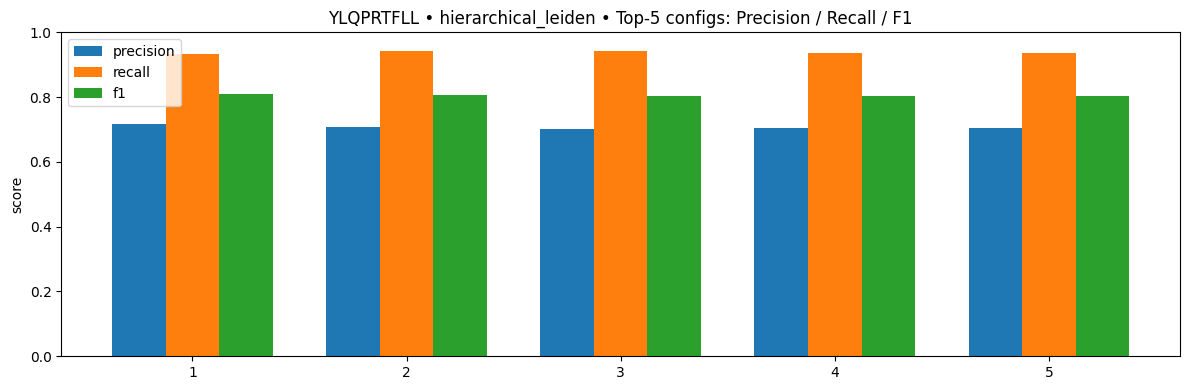

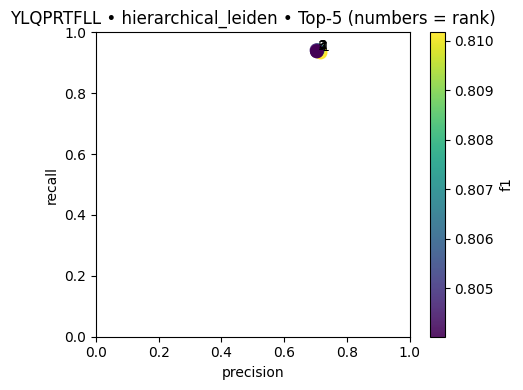

,config__,precision__,recall__,f1__,f1
0,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.732919,0.921875,0.816609,0.816609
1,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.732704,0.910156,0.811847,0.811847
2,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.707692,0.898438,0.791738,0.791738
3,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.695783,0.902344,0.785714,0.785714
4,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.691617,0.902344,0.783051,0.783051


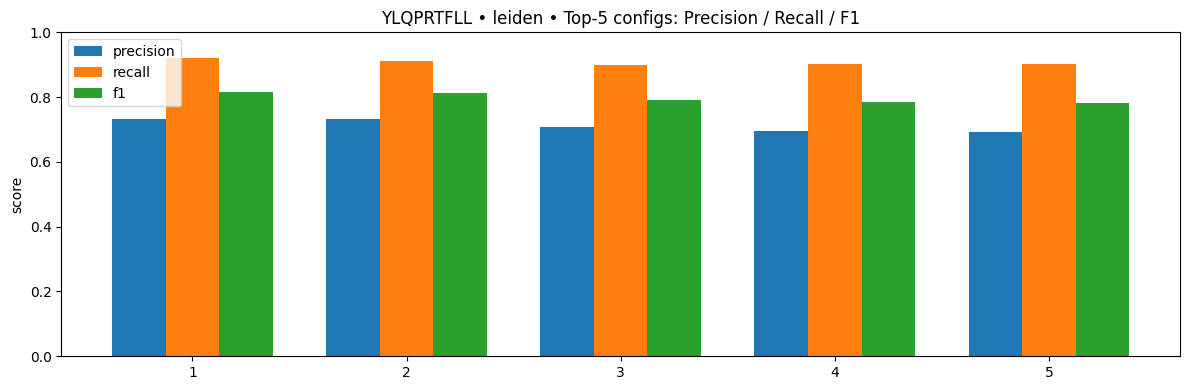

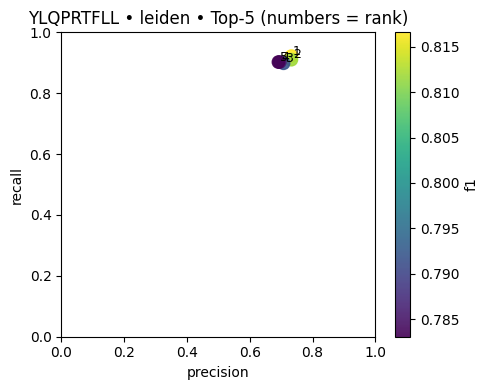

,config__,precision__,recall__,f1__,f1
0,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.708861,0.875000,0.783217,0.783217
1,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.689231,0.875000,0.771084,0.771084
2,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.687307,0.867188,0.766839,0.766839
3,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.681957,0.871094,0.765009,0.765009
4,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.681957,0.871094,0.765009,0.765009


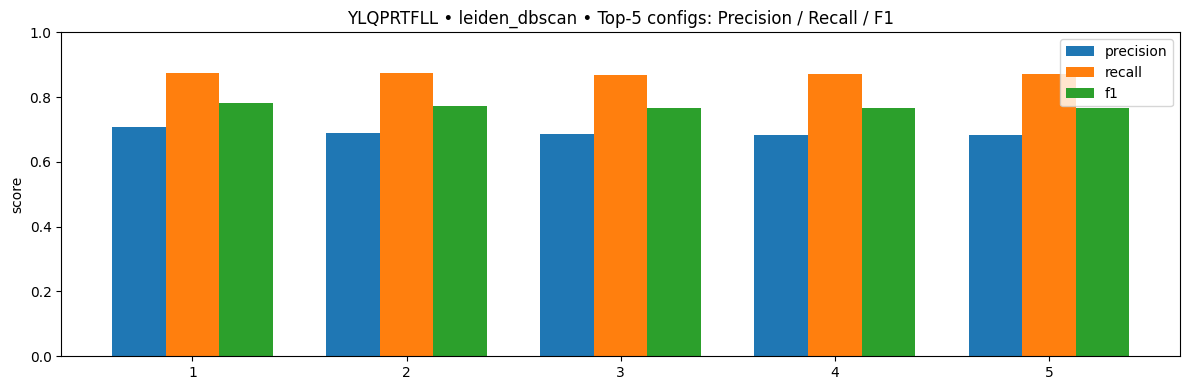

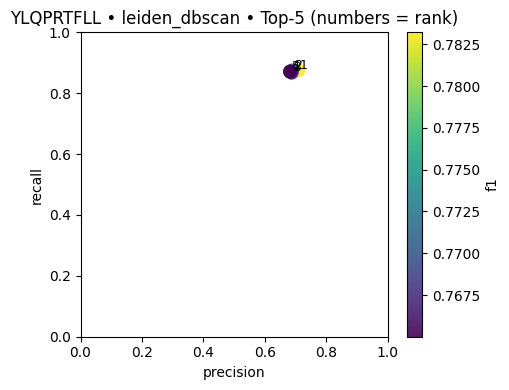

,config__,precision__,recall__,f1__,f1
0,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.631148,0.902344,0.742765,0.742765
1,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.628415,0.898438,0.739550,0.739550
2,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.560811,0.972656,0.711429,0.711429
3,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.559551,0.972656,0.710414,0.710414
4,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.558296,0.972656,0.709402,0.709402


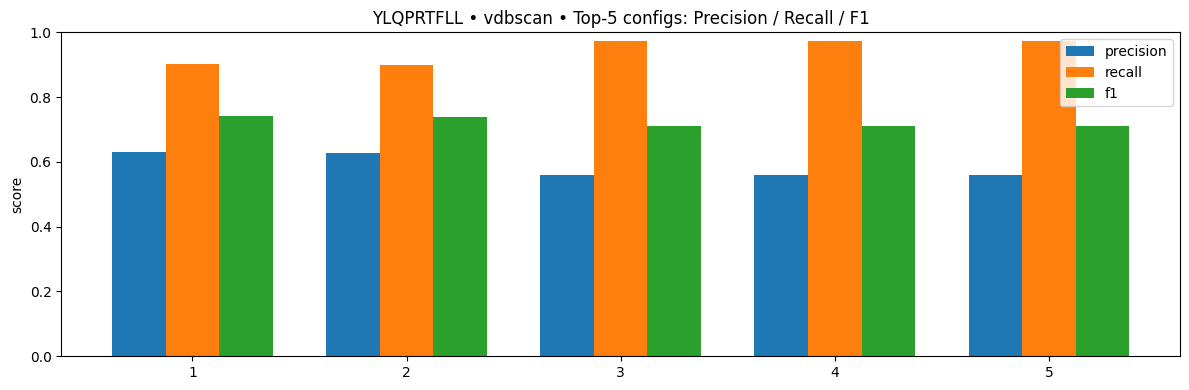

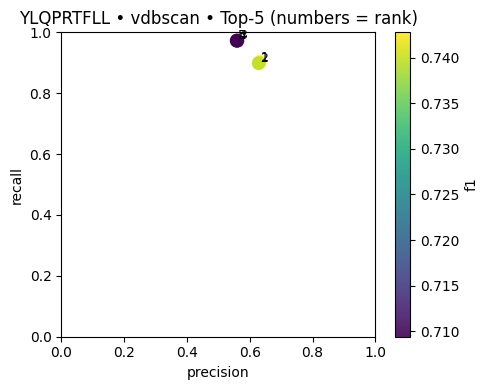

,config__,precision__,recall__,f1__,f1
0,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.856540,0.918552,0.886463,0.886463
1,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.858051,0.916290,0.886214,0.886214
2,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.865510,0.902715,0.883721,0.883721
3,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.865510,0.902715,0.883721,0.883721
4,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.865510,0.902715,0.883721,0.883721


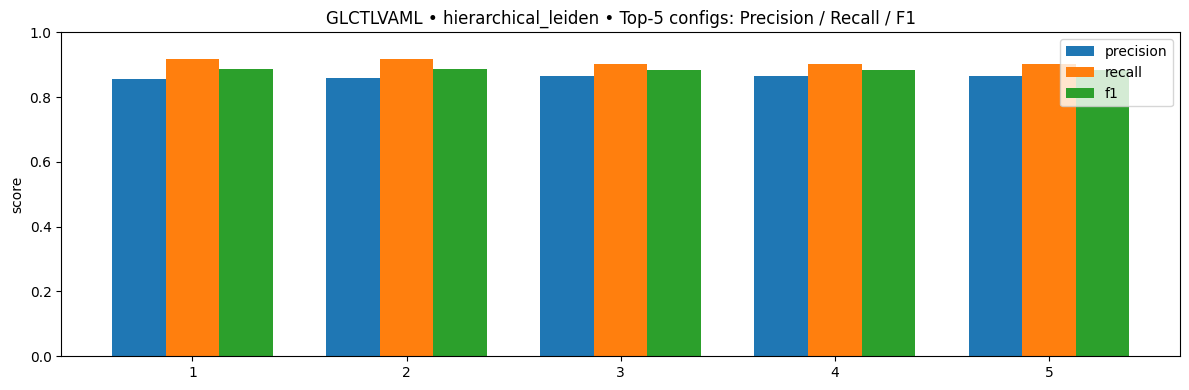

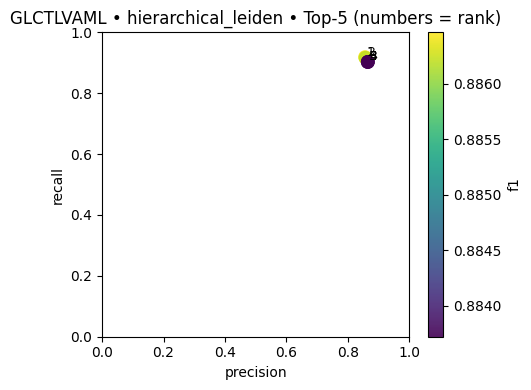

,config__,precision__,recall__,f1__,f1
0,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.868526,0.986425,0.923729,0.923729
1,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.868000,0.981900,0.921444,0.921444
2,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.861933,0.988688,0.920969,0.920969
3,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.860236,0.988688,0.920000,0.920000
4,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.860236,0.988688,0.920000,0.920000


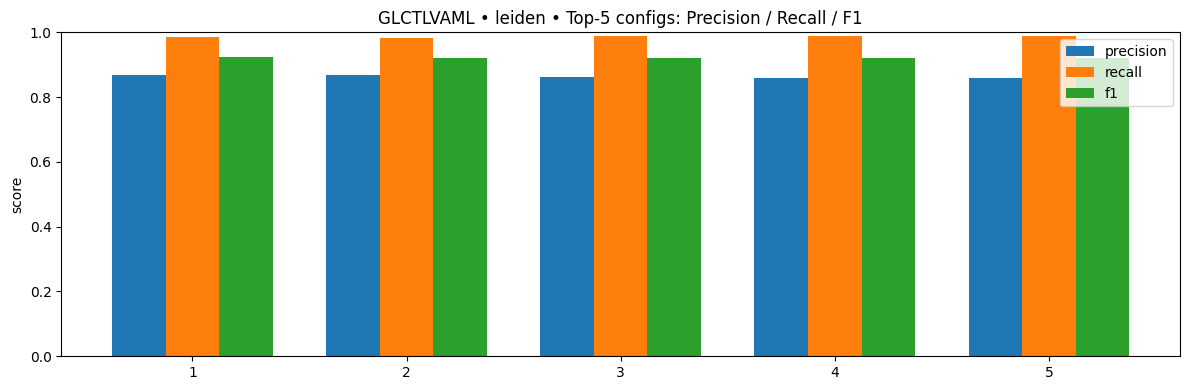

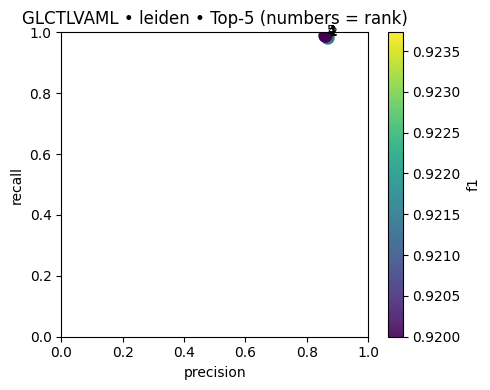

,config__,precision__,recall__,f1__,f1
0,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.858824,0.990950,0.920168,0.920168
1,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.859961,0.986425,0.918862,0.918862
2,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.856863,0.988688,0.918067,0.918067
3,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.856582,0.986425,0.916930,0.916930
4,run_dir=/projects/immunestatus/vdjdb/tcrempnet...,0.857988,0.984163,0.916754,0.916754


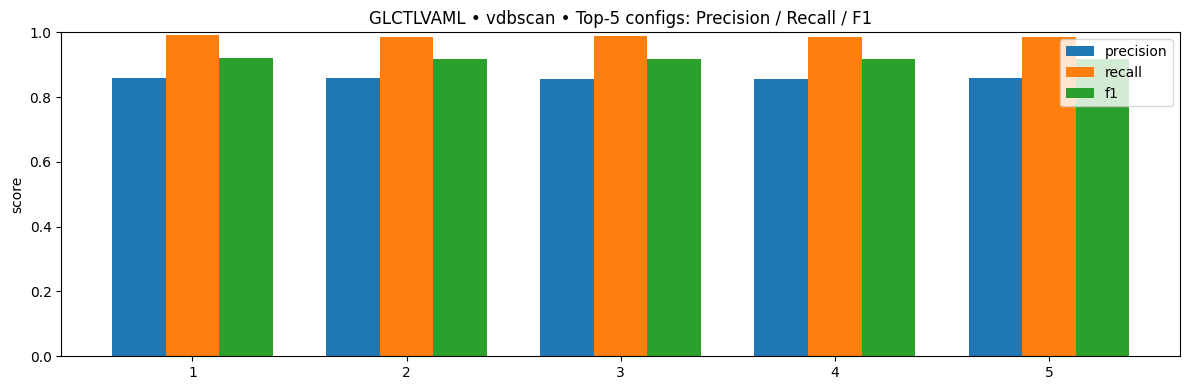

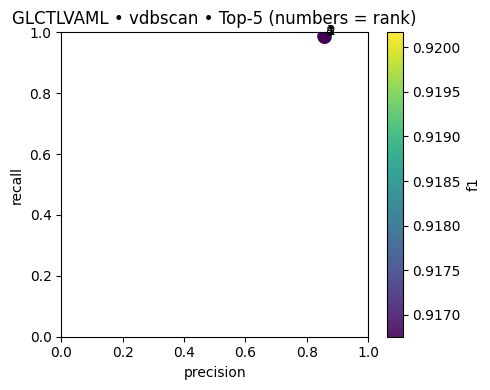

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def infer_prf_columns(df: pd.DataFrame):
    cols = {c.lower(): c for c in df.columns}
    p = cols.get("precision") or next((cols[k] for k in cols if "precision" in k), None)
    r = cols.get("recall")    or next((cols[k] for k in cols if "recall" in k), None)
    f = cols.get("f1")        or next((cols[k] for k in cols if k.startswith("f1") or "f1" in k), None)
    return p, r, f

def compute_prf_from_counts(df: pd.DataFrame):
    cols = {c.lower(): c for c in df.columns}
    tp = cols.get("tp")
    fp = cols.get("fp")
    fn = cols.get("fn")
    if not (tp and fp and fn):
        return None  # не из чего посчитать
    tpv = pd.to_numeric(df[tp], errors="coerce")
    fpv = pd.to_numeric(df[fp], errors="coerce")
    fnv = pd.to_numeric(df[fn], errors="coerce")
    precision = tpv / (tpv + fpv + 1e-12)
    recall    = tpv / (tpv + fnv + 1e-12)
    f1        = 2 * precision * recall / (precision + recall + 1e-12)
    return precision, recall, f1

def top5_prf_table(df: pd.DataFrame, score_col: str, topk: int = 5) -> pd.DataFrame:
    d = df.copy()
    d[score_col] = pd.to_numeric(d[score_col], errors="coerce")
    d = d.sort_values(score_col, ascending=False).head(topk).copy()

    p_col, r_col, f_col = infer_prf_columns(d)

    if p_col and r_col and f_col:
        d["precision__"] = pd.to_numeric(d[p_col], errors="coerce")
        d["recall__"]    = pd.to_numeric(d[r_col], errors="coerce")
        d["f1__"]        = pd.to_numeric(d[f_col], errors="coerce")
    else:
        prf = compute_prf_from_counts(d)
        if prf is None:
            raise ValueError("Не нашёл precision/recall/f1 и не могу посчитать из tp/fp/fn.")
        d["precision__"], d["recall__"], d["f1__"] = prf

    # компактная подпись конфига: возьмём все не-метрические колонки (или только params, если у тебя есть infer_param_columns)
    metric_like = set(infer_metric_columns(d)) | {score_col, "precision__", "recall__", "f1__"}
    param_cols = [c for c in d.columns if c not in metric_like and d[c].nunique() > 1]
    if len(param_cols) > 0:
        d["config__"] = d[param_cols].astype(str).agg(lambda row: ", ".join([f"{c}={row[c]}" for c in param_cols]), axis=1)
    else:
        d["config__"] = [f"rank#{i+1}" for i in range(len(d))]

    return d[["config__", "precision__", "recall__", "f1__", score_col]]

def plot_top5_prf(epitope: str, algo: str, top5: pd.DataFrame):
    # grouped bars: for each config show P/R/F1
    plt.figure(figsize=(12, 4))
    x = np.arange(len(top5))
    w = 0.25
    plt.bar(x - w, top5["precision__"].values, width=w, label="precision")
    plt.bar(x,      top5["recall__"].values,    width=w, label="recall")
    plt.bar(x + w,  top5["f1__"].values,        width=w, label="f1")

    plt.xticks(x, [f"{i+1}" for i in range(len(top5))])
    plt.ylim(0, 1.0)
    plt.ylabel("score")
    plt.title(f"{epitope} • {algo} • Top-5 configs: Precision / Recall / F1")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # (опционально) scatter precision vs recall colored by f1
    plt.figure(figsize=(5, 4))
    sc = plt.scatter(top5["precision__"], top5["recall__"], c=top5["f1__"], s=80, alpha=0.9)
    plt.colorbar(sc, label="f1")
    for i, row in enumerate(top5.itertuples(index=False), start=1):
        plt.text(row.precision__ + 0.005, row.recall__ + 0.005, str(i), fontsize=9)
    plt.xlim(0, 1.0); plt.ylim(0, 1.0)
    plt.xlabel("precision"); plt.ylabel("recall")
    plt.title(f"{epitope} • {algo} • Top-5 (numbers = rank)")
    plt.tight_layout()
    plt.show()

# --- запуск по всему all_metrics ---
TOPK = 5

for epitope, ep_dict in all_metrics.items():
    for algo, df in ep_dict.items():
        score_col = infer_score_column(df)
        top5 = top5_prf_table(df, score_col=score_col, topk=TOPK)
        display(top5)
        plot_top5_prf(epitope, algo, top5)


In [30]:
all_metrics['YLQPRTFLL']['leiden']

,run_dir,status,kn,ms,eps_mode,eps,relpath,tags,lr,TP,FP,TN,FN,precision,recall,f1,n_eval,n_total,n_clustered
0,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,4,NaN,NaN,NaN,kn_4/lr_2.0,NaN,2.0,236,86,165,20,0.732919,0.921875,0.816609,507,1081,765
1,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,4,NaN,NaN,NaN,kn_4/lr_3.0,NaN,3.0,233,85,166,23,0.732704,0.910156,0.811847,507,1081,759
2,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,8,NaN,NaN,NaN,kn_8/lr_3.0,NaN,3.0,230,95,156,26,0.707692,0.898438,0.791738,507,1081,778
3,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,4,NaN,NaN,NaN,kn_4/lr_1.0,NaN,1.0,231,101,150,25,0.695783,0.902344,0.785714,507,1081,784
4,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,8,NaN,NaN,NaN,kn_8/lr_2.0,NaN,2.0,231,103,148,25,0.691617,0.902344,0.783051,507,1081,793
5,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,4,NaN,NaN,NaN,kn_4/lr_0.5,NaN,0.5,232,108,143,24,0.682353,0.906250,0.778523,507,1081,799
6,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,12,NaN,NaN,NaN,kn_12/lr_3.0,NaN,3.0,224,107,144,32,0.676737,0.875000,0.763203,507,1081,796
7,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,16,NaN,NaN,NaN,kn_16/lr_3.0,NaN,3.0,224,113,138,32,0.664688,0.875000,0.755481,507,1081,808
8,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,12,NaN,NaN,NaN,kn_12/lr_2.0,NaN,2.0,224,121,130,32,0.649275,0.875000,0.745424,507,1081,821
9,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,8,NaN,NaN,NaN,kn_8/lr_1.0,NaN,1.0,220,116,135,36,0.654762,0.859375,0.743243,507,1081,805



=== YLQPRTFLL baseline (TCRnet, β) ===
{'precision': 0.7278481012658228, 'recall': 0.6686046511627907, 'f1': 0.696969696969697}


,_algo,_score_col,_best_score
0,leiden,f1,0.816609
1,hierarchical_leiden,f1,0.810169
2,leiden_dbscan,f1,0.783217
3,vdbscan,f1,0.742765


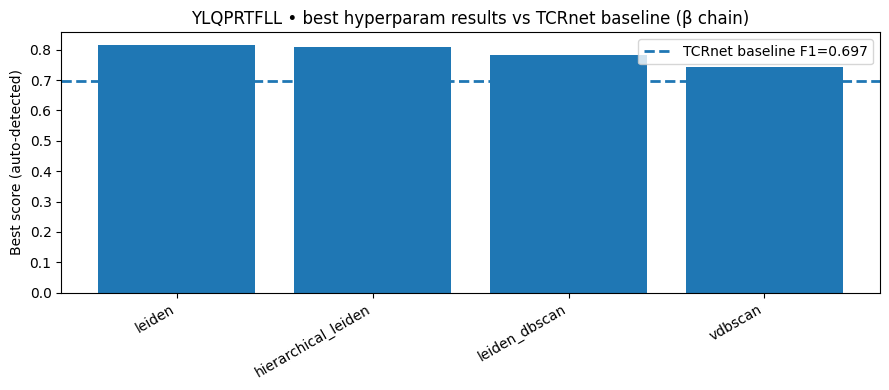


--- YLQPRTFLL • hierarchical_leiden ---
score_col: f1
param_cols: ['kn', 'ms', 'eps_mode', 'eps', 'tags', 'lr', 'slr', 'n_eval', 'n_total']


,run_dir,status,kn,ms,eps_mode,eps,relpath,tags,lr,slr,TP,FP,TN,FN,precision,recall,f1,n_eval,n_total,n_clustered
0,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,16,NaN,NaN,NaN,kn_16/lr_1.0__slr_2.0,NaN,1.0,2.0,239,95,156,17,0.715569,0.933594,0.810169,507,1081,790
1,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,12,NaN,NaN,NaN,kn_12/lr_1.0__slr_2.0,NaN,1.0,2.0,241,100,151,15,0.706745,0.941406,0.807370,507,1081,800
2,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,12,NaN,NaN,NaN,kn_12/lr_0.5__slr_2.0,NaN,0.5,2.0,241,102,149,15,0.702624,0.941406,0.804674,507,1081,800
3,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,12,NaN,NaN,NaN,kn_12/lr_2.0__slr_2.0,NaN,2.0,2.0,240,101,150,16,0.703812,0.937500,0.804020,507,1081,805
4,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,16,NaN,NaN,NaN,kn_16/lr_0.5__slr_3.0,NaN,0.5,3.0,240,101,150,16,0.703812,0.937500,0.804020,507,1081,798
5,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,16,NaN,NaN,NaN,kn_16/lr_2.0__slr_2.0,NaN,2.0,2.0,238,99,152,18,0.706231,0.929688,0.802698,507,1081,789
6,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,16,NaN,NaN,NaN,kn_16/lr_3.0__slr_2.0,NaN,3.0,2.0,238,99,152,18,0.706231,0.929688,0.802698,507,1081,794
7,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,12,NaN,NaN,NaN,kn_12/lr_0.5__slr_3.0,NaN,0.5,3.0,238,101,150,18,0.702065,0.929688,0.800000,507,1081,800
8,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,16,NaN,NaN,NaN,kn_16/lr_1.0__slr_3.0,NaN,1.0,3.0,238,101,150,18,0.702065,0.929688,0.800000,507,1081,794
9,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,8,NaN,NaN,NaN,kn_8/lr_0.5__slr_2.0,NaN,0.5,2.0,238,101,150,18,0.702065,0.929688,0.800000,507,1081,801


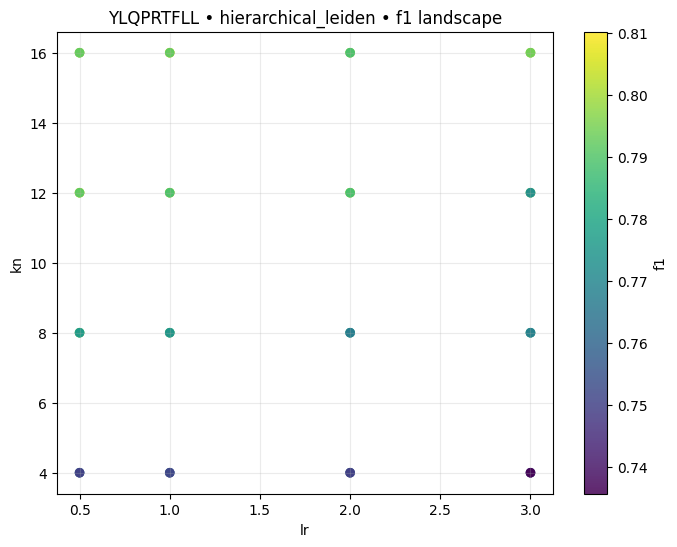


--- YLQPRTFLL • leiden ---
score_col: f1
param_cols: ['kn', 'ms', 'eps_mode', 'eps', 'tags', 'lr', 'n_eval', 'n_total']


,run_dir,status,kn,ms,eps_mode,eps,relpath,tags,lr,TP,FP,TN,FN,precision,recall,f1,n_eval,n_total,n_clustered
0,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,4,NaN,NaN,NaN,kn_4/lr_2.0,NaN,2.0,236,86,165,20,0.732919,0.921875,0.816609,507,1081,765
1,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,4,NaN,NaN,NaN,kn_4/lr_3.0,NaN,3.0,233,85,166,23,0.732704,0.910156,0.811847,507,1081,759
2,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,8,NaN,NaN,NaN,kn_8/lr_3.0,NaN,3.0,230,95,156,26,0.707692,0.898438,0.791738,507,1081,778
3,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,4,NaN,NaN,NaN,kn_4/lr_1.0,NaN,1.0,231,101,150,25,0.695783,0.902344,0.785714,507,1081,784
4,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,8,NaN,NaN,NaN,kn_8/lr_2.0,NaN,2.0,231,103,148,25,0.691617,0.902344,0.783051,507,1081,793
5,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,4,NaN,NaN,NaN,kn_4/lr_0.5,NaN,0.5,232,108,143,24,0.682353,0.906250,0.778523,507,1081,799
6,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,12,NaN,NaN,NaN,kn_12/lr_3.0,NaN,3.0,224,107,144,32,0.676737,0.875000,0.763203,507,1081,796
7,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,16,NaN,NaN,NaN,kn_16/lr_3.0,NaN,3.0,224,113,138,32,0.664688,0.875000,0.755481,507,1081,808
8,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,12,NaN,NaN,NaN,kn_12/lr_2.0,NaN,2.0,224,121,130,32,0.649275,0.875000,0.745424,507,1081,821
9,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,8,NaN,NaN,NaN,kn_8/lr_1.0,NaN,1.0,220,116,135,36,0.654762,0.859375,0.743243,507,1081,805


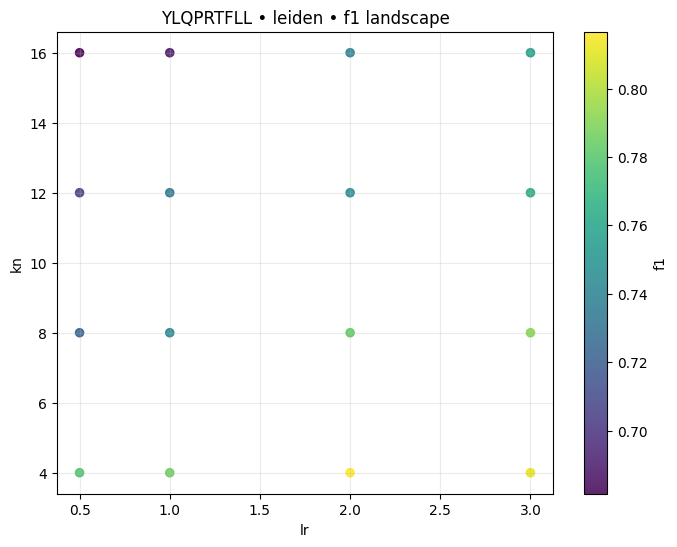


--- YLQPRTFLL • leiden_dbscan ---
score_col: f1
param_cols: ['kn', 'ms', 'eps_mode', 'eps', 'tags', 'lr', 'n_eval', 'n_total']


,run_dir,status,kn,ms,eps_mode,eps,relpath,tags,lr,TP,FP,TN,FN,precision,recall,f1,n_eval,n_total,n_clustered
0,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,12,10,NaN,NaN,kn_12/lr_3.0__ms_10,NaN,3.0,224,92,159,32,0.708861,0.875000,0.783217,507,1081,769
1,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,16,10,NaN,NaN,kn_16/lr_3.0__ms_10,NaN,3.0,224,101,150,32,0.689231,0.875000,0.771084,507,1081,781
2,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,12,3,NaN,NaN,kn_12/lr_3.0__ms_3,NaN,3.0,222,101,150,34,0.687307,0.867188,0.766839,507,1081,775
3,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,12,10,NaN,NaN,kn_12/lr_2.0__ms_10,NaN,2.0,223,104,147,33,0.681957,0.871094,0.765009,507,1081,784
4,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,16,3,NaN,NaN,kn_16/lr_3.0__ms_3,NaN,3.0,223,104,147,33,0.681957,0.871094,0.765009,507,1081,793
5,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,12,5,NaN,NaN,kn_12/lr_3.0__ms_5,NaN,3.0,224,108,143,32,0.674699,0.875000,0.761905,507,1081,794
6,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,16,5,NaN,NaN,kn_16/lr_3.0__ms_5,NaN,3.0,223,110,141,33,0.669670,0.871094,0.757216,507,1081,798
7,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,12,3,NaN,NaN,kn_12/lr_2.0__ms_3,NaN,2.0,219,106,145,37,0.673846,0.855469,0.753873,507,1081,775
8,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,12,5,NaN,NaN,kn_12/lr_2.0__ms_5,NaN,2.0,223,114,137,33,0.661721,0.871094,0.752108,507,1081,798
9,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,16,10,NaN,NaN,kn_16/lr_2.0__ms_10,NaN,2.0,224,118,133,32,0.654971,0.875000,0.749164,507,1081,815


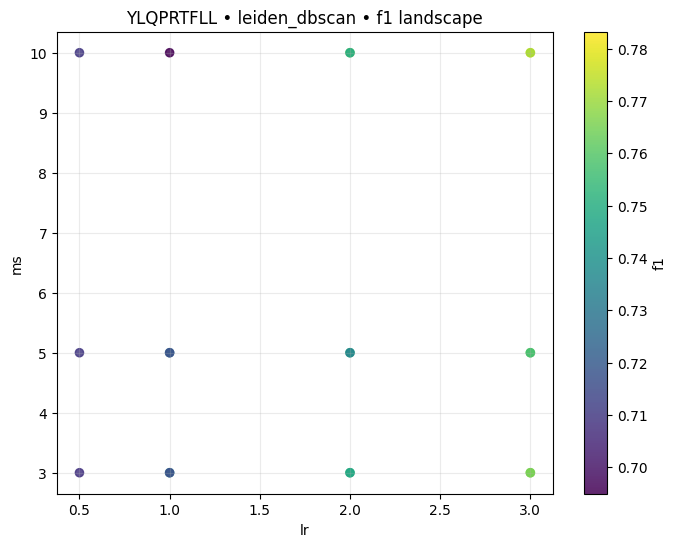


--- YLQPRTFLL • vdbscan ---
score_col: f1
param_cols: ['kn', 'ms', 'eps', 'tags', 'n_eval', 'n_total']


,run_dir,status,kn,ms,eps_mode,eps,relpath,tags,TP,FP,TN,FN,precision,recall,f1,n_eval,n_total,n_clustered
0,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,4,3,all,NaN,kn_4/ms_3__eps_all,NaN,231,135,116,25,0.631148,0.902344,0.742765,507,1081,833
1,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,4,3,background,NaN,kn_4/ms_3__eps_background,NaN,230,136,115,26,0.628415,0.898438,0.739550,507,1081,832
2,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,12,5,all,NaN,kn_12/ms_5__eps_all,NaN,249,195,56,7,0.560811,0.972656,0.711429,507,1081,980
3,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,12,5,background,NaN,kn_12/ms_5__eps_background,NaN,249,196,55,7,0.559551,0.972656,0.710414,507,1081,980
4,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,12,3,all,NaN,kn_12/ms_3__eps_all,NaN,249,197,54,7,0.558296,0.972656,0.709402,507,1081,980
5,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,12,3,background,NaN,kn_12/ms_3__eps_background,NaN,249,197,54,7,0.558296,0.972656,0.709402,507,1081,980
6,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,8,3,background,NaN,kn_8/ms_3__eps_background,NaN,238,177,74,18,0.573494,0.929688,0.709389,507,1081,941
7,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,16,10,all,NaN,kn_16/ms_10__eps_all,NaN,246,192,59,10,0.561644,0.960938,0.708934,507,1081,957
8,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,8,3,all,NaN,kn_8/ms_3__eps_all,NaN,238,178,73,18,0.572115,0.929688,0.708333,507,1081,941
9,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,ok,16,10,background,NaN,kn_16/ms_10__eps_background,NaN,247,195,56,9,0.558824,0.964844,0.707736,507,1081,969


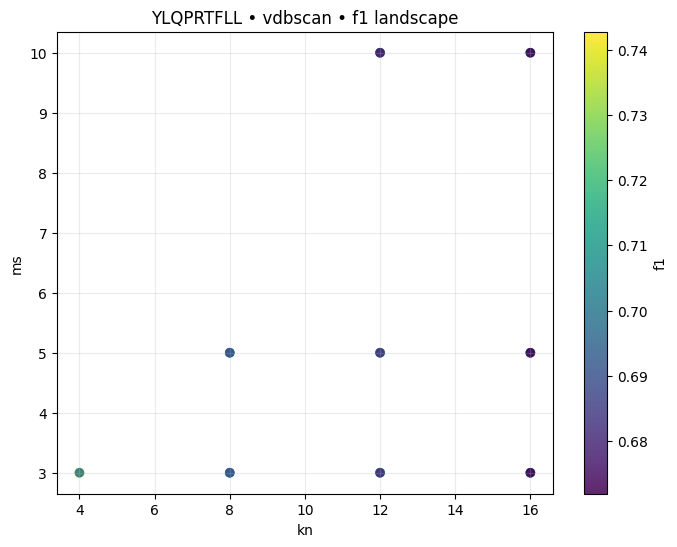


=== GLCTLVAML baseline (TCRnet, β) ===
{'precision': 0.7222222222222222, 'recall': 0.48507462686567165, 'f1': 0.5803571428571429}


,_algo,_score_col,_best_score
0,leiden,f1,0.923729
1,vdbscan,f1,0.920168
2,hierarchical_leiden,f1,0.886463


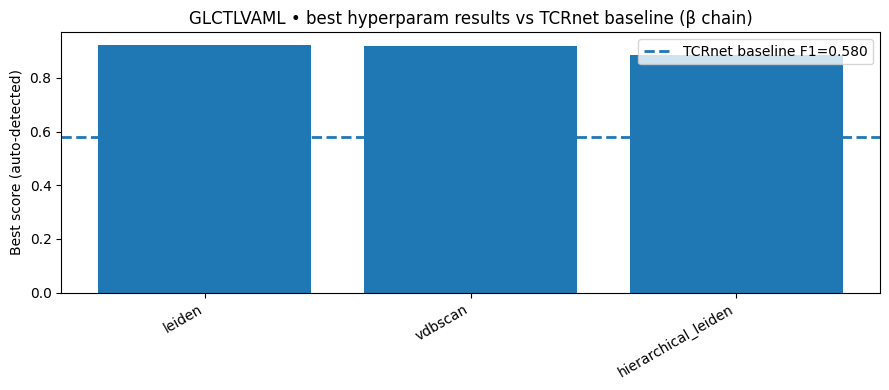


--- GLCTLVAML • hierarchical_leiden ---
score_col: f1
param_cols: ['kn', 'ms', 'eps_mode', 'eps', 'tags', 'lr', 'slr', 'n_eval', 'n_total']


,run_dir,status,kn,ms,eps_mode,eps,relpath,tags,lr,slr,TP,FP,TN,FN,precision,recall,f1,n_eval,n_total,n_clustered
0,/projects/immunestatus/vdjdb/tcrempnet_GLCTLVA...,ok,16,NaN,NaN,NaN,kn_16/lr_0.5__slr_2.0,NaN,0.5,2.0,406,68,5,36,0.856540,0.918552,0.886463,515,3211,2333
1,/projects/immunestatus/vdjdb/tcrempnet_GLCTLVA...,ok,16,NaN,NaN,NaN,kn_16/lr_3.0__slr_4.0,NaN,3.0,4.0,405,67,6,37,0.858051,0.916290,0.886214,515,3211,2314
2,/projects/immunestatus/vdjdb/tcrempnet_GLCTLVA...,ok,4,NaN,NaN,NaN,kn_4/lr_0.5__slr_3.0,NaN,0.5,3.0,399,62,11,43,0.865510,0.902715,0.883721,515,3211,2198
3,/projects/immunestatus/vdjdb/tcrempnet_GLCTLVA...,ok,4,NaN,NaN,NaN,kn_4/lr_1.0__slr_3.0,NaN,1.0,3.0,399,62,11,43,0.865510,0.902715,0.883721,515,3211,2201
4,/projects/immunestatus/vdjdb/tcrempnet_GLCTLVA...,ok,4,NaN,NaN,NaN,kn_4/lr_1.0__slr_4.0,NaN,1.0,4.0,399,62,11,43,0.865510,0.902715,0.883721,515,3211,2194
5,/projects/immunestatus/vdjdb/tcrempnet_GLCTLVA...,ok,4,NaN,NaN,NaN,kn_4/lr_2.0__slr_3.0,NaN,2.0,3.0,399,62,11,43,0.865510,0.902715,0.883721,515,3211,2200
6,/projects/immunestatus/vdjdb/tcrempnet_GLCTLVA...,ok,4,NaN,NaN,NaN,kn_4/lr_2.0__slr_4.0,NaN,2.0,4.0,400,65,8,42,0.860215,0.904977,0.882029,515,3211,2207
7,/projects/immunestatus/vdjdb/tcrempnet_GLCTLVA...,ok,4,NaN,NaN,NaN,kn_4/lr_0.5__slr_2.0,NaN,0.5,2.0,399,64,9,43,0.861771,0.902715,0.881768,515,3211,2259
8,/projects/immunestatus/vdjdb/tcrempnet_GLCTLVA...,ok,4,NaN,NaN,NaN,kn_4/lr_2.0__slr_2.0,NaN,2.0,2.0,398,64,9,44,0.861472,0.900452,0.880531,515,3211,2229
9,/projects/immunestatus/vdjdb/tcrempnet_GLCTLVA...,ok,4,NaN,NaN,NaN,kn_4/lr_3.0__slr_4.0,NaN,3.0,4.0,397,63,10,45,0.863043,0.898190,0.880266,515,3211,2198


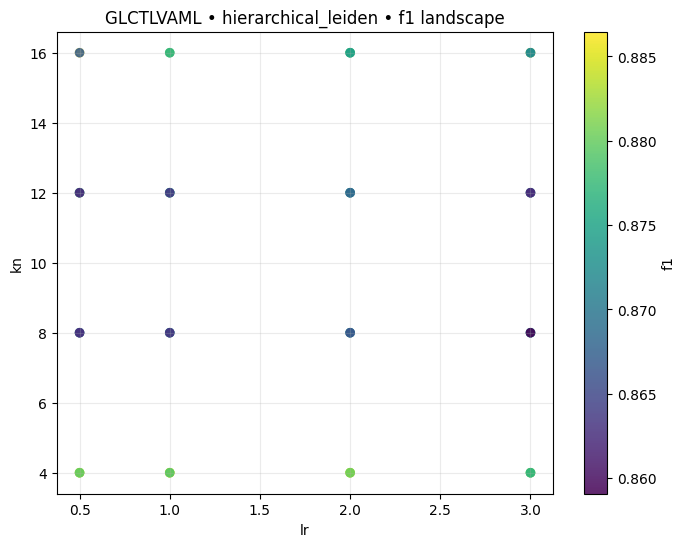


--- GLCTLVAML • leiden ---
score_col: f1
param_cols: ['kn', 'ms', 'eps_mode', 'eps', 'tags', 'lr', 'n_eval', 'n_total']


,run_dir,status,kn,ms,eps_mode,eps,relpath,tags,lr,TP,FP,TN,FN,precision,recall,f1,n_eval,n_total,n_clustered
0,/projects/immunestatus/vdjdb/tcrempnet_GLCTLVA...,ok,4,NaN,NaN,NaN,kn_4/lr_2.0,NaN,2.0,436,66,7,6,0.868526,0.986425,0.923729,515,3211,2870
1,/projects/immunestatus/vdjdb/tcrempnet_GLCTLVA...,ok,4,NaN,NaN,NaN,kn_4/lr_3.0,NaN,3.0,434,66,7,8,0.868000,0.981900,0.921444,515,3211,2843
2,/projects/immunestatus/vdjdb/tcrempnet_GLCTLVA...,ok,12,NaN,NaN,NaN,kn_12/lr_0.5,NaN,0.5,437,70,3,5,0.861933,0.988688,0.920969,515,3211,2990
3,/projects/immunestatus/vdjdb/tcrempnet_GLCTLVA...,ok,16,NaN,NaN,NaN,kn_16/lr_0.5,NaN,0.5,437,71,2,5,0.860236,0.988688,0.920000,515,3211,2994
4,/projects/immunestatus/vdjdb/tcrempnet_GLCTLVA...,ok,16,NaN,NaN,NaN,kn_16/lr_2.0,NaN,2.0,437,71,2,5,0.860236,0.988688,0.920000,515,3211,2991
5,/projects/immunestatus/vdjdb/tcrempnet_GLCTLVA...,ok,16,NaN,NaN,NaN,kn_16/lr_1.0,NaN,1.0,436,70,3,6,0.861660,0.986425,0.919831,515,3211,3056
6,/projects/immunestatus/vdjdb/tcrempnet_GLCTLVA...,ok,4,NaN,NaN,NaN,kn_4/lr_1.0,NaN,1.0,436,70,3,6,0.861660,0.986425,0.919831,515,3211,2989
7,/projects/immunestatus/vdjdb/tcrempnet_GLCTLVA...,ok,8,NaN,NaN,NaN,kn_8/lr_2.0,NaN,2.0,436,70,3,6,0.861660,0.986425,0.919831,515,3211,2996
8,/projects/immunestatus/vdjdb/tcrempnet_GLCTLVA...,ok,16,NaN,NaN,NaN,kn_16/lr_3.0,NaN,3.0,435,69,4,7,0.863095,0.984163,0.919662,515,3211,2938
9,/projects/immunestatus/vdjdb/tcrempnet_GLCTLVA...,ok,12,NaN,NaN,NaN,kn_12/lr_1.0,NaN,1.0,435,70,3,7,0.861386,0.984163,0.918691,515,3211,2972


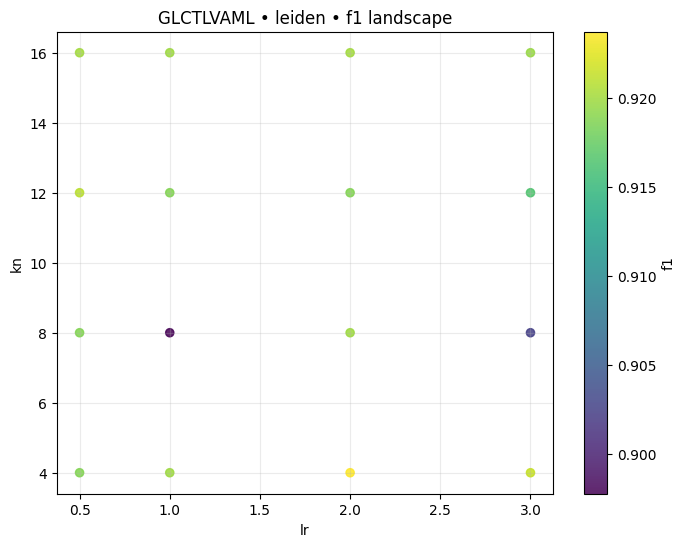


--- GLCTLVAML • vdbscan ---
score_col: f1
param_cols: ['kn', 'ms', 'eps', 'tags', 'n_eval', 'n_total']


,run_dir,status,kn,ms,eps_mode,eps,relpath,tags,TP,FP,TN,FN,precision,recall,f1,n_eval,n_total,n_clustered
0,/projects/immunestatus/vdjdb/tcrempnet_GLCTLVA...,ok,16,3,background,NaN,kn_16/ms_3__eps_background,NaN,438,72,1,4,0.858824,0.990950,0.920168,515,3211,3134
1,/projects/immunestatus/vdjdb/tcrempnet_GLCTLVA...,ok,16,5,background,NaN,kn_16/ms_5__eps_background,NaN,436,71,2,6,0.859961,0.986425,0.918862,515,3211,3094
2,/projects/immunestatus/vdjdb/tcrempnet_GLCTLVA...,ok,16,3,sample,NaN,kn_16/ms_3__eps_sample,NaN,437,73,0,5,0.856863,0.988688,0.918067,515,3211,3119
3,/projects/immunestatus/vdjdb/tcrempnet_GLCTLVA...,ok,4,3,sample,NaN,kn_4/ms_3__eps_sample,NaN,436,73,0,6,0.856582,0.986425,0.916930,515,3211,2975
4,/projects/immunestatus/vdjdb/tcrempnet_GLCTLVA...,ok,16,3,all,NaN,kn_16/ms_3__eps_all,NaN,435,72,1,7,0.857988,0.984163,0.916754,515,3211,3071
5,/projects/immunestatus/vdjdb/tcrempnet_GLCTLVA...,ok,8,3,sample,NaN,kn_8/ms_3__eps_sample,NaN,435,72,1,7,0.857988,0.984163,0.916754,515,3211,3058
6,/projects/immunestatus/vdjdb/tcrempnet_GLCTLVA...,ok,12,5,background,NaN,kn_12/ms_5__eps_background,NaN,434,71,2,8,0.859406,0.981900,0.916579,515,3211,3056
7,/projects/immunestatus/vdjdb/tcrempnet_GLCTLVA...,ok,12,10,background,NaN,kn_12/ms_10__eps_background,NaN,433,70,3,9,0.860835,0.979638,0.916402,515,3211,3030
8,/projects/immunestatus/vdjdb/tcrempnet_GLCTLVA...,ok,16,10,background,NaN,kn_16/ms_10__eps_background,NaN,433,70,3,9,0.860835,0.979638,0.916402,515,3211,3034
9,/projects/immunestatus/vdjdb/tcrempnet_GLCTLVA...,ok,12,3,background,NaN,kn_12/ms_3__eps_background,NaN,434,72,1,8,0.857708,0.981900,0.915612,515,3211,3076


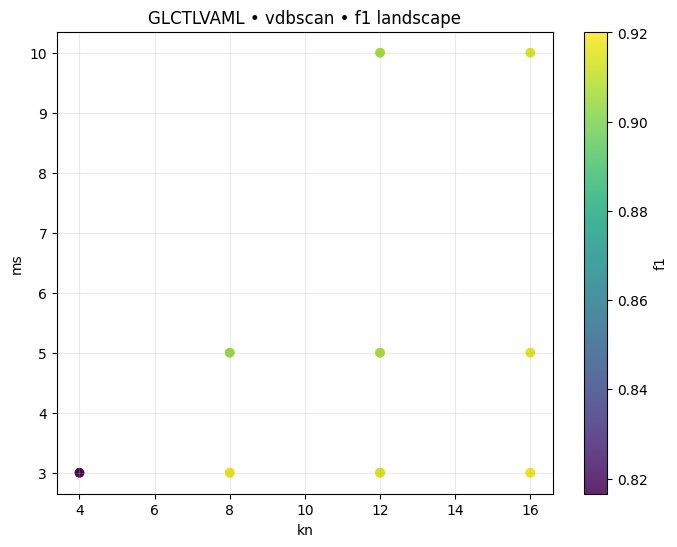

In [14]:

def summarize_best_by_algo(ep_metrics: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    for algo, df in ep_metrics.items():
        if df is None or len(df) == 0:
            continue
        score_col = infer_score_column(df)
        d = df.copy()
        d[score_col] = safe_to_numeric(d[score_col])
        best_idx = d[score_col].idxmax()
        best = d.loc[best_idx].to_dict()
        best["_algo"] = algo
        best["_score_col"] = score_col
        best["_best_score"] = float(d.loc[best_idx, score_col])
        rows.append(best)
    if not rows:
        return pd.DataFrame()
    out = pd.DataFrame(rows)
    out = out.sort_values("_best_score", ascending=False)
    return out


def plot_best_comparison(epitope: str, best_df: pd.DataFrame, baseline: Dict[str, float]):
    if best_df.empty:
        print(f"No metrics tables found for {epitope}")
        return

    # primary score: use each algo's own score col, but we will plot _best_score (already extracted)
    labels = list(best_df["_algo"])
    scores = list(best_df["_best_score"])

    plt.figure(figsize=(9, 4))
    x = np.arange(len(labels))
    plt.bar(x, scores)
    plt.axhline(baseline["f1"], linestyle="--", linewidth=2, label=f"TCRnet baseline F1={baseline['f1']:.3f}")
    plt.xticks(x, labels, rotation=30, ha="right")
    plt.ylabel("Best score (auto-detected)")
    plt.title(f"{epitope} • best hyperparam results vs TCRnet baseline (β chain)")
    plt.legend()
    plt.tight_layout()
    plt.show()


def run_epitope_report(epitope: str, ep_metrics: Dict[str, pd.DataFrame], baseline_use_vj: bool = False):
    # Baseline
    motifs, tcrvdb = load_inputs_for_epitope(epitope)
    baseline = compute_tcrnet_baseline(motifs, tcrvdb, use_vj=baseline_use_vj)
    print(f"\n=== {epitope} baseline (TCRnet, β) ===")
    print(baseline)

    # Best summary
    best_df = summarize_best_by_algo(ep_metrics)
    display(best_df[["_algo", "_score_col", "_best_score"]].reset_index(drop=True) if not best_df.empty else best_df)
    plot_best_comparison(epitope, best_df, baseline)

    # Per-algo visualizations
    for algo, df in ep_metrics.items():
        if df is None or len(df) == 0:
            continue
        score_col = infer_score_column(df)
        param_cols = infer_param_columns(df, score_col)

        print(f"\n--- {epitope} • {algo} ---")
        print("score_col:", score_col)
        print("param_cols:", param_cols)
        display(top_configs_table(df, score_col, n=TOP_N_TABLE))
        plot_param_landscape(df, algo=algo, epitope=epitope, score_col=score_col, param_cols=param_cols)


# Run reports
for ep in EPITOPES:
    if ep not in all_metrics:
        continue
    run_epitope_report(ep, all_metrics[ep], baseline_use_vj=False)  # set True if you want VJ-aware baseline too


In [ ]:
* top по статьям
* кто такой negative? высокий pgen, должен был попасть но не попал
* GIL + NLV / CMV еще -- посмотреть какие встречаются и там и там, так отобрать какой-то пул негативных
* добавить в эпитоп 10% (30-50 как в Matchmakers) GIL <-> NLV, случайные записи из всей vdjdb (чтобы не было кластеринга)
* посмотреть стабильность параметров, число k
* odds ratio

## Cross-epitope comparison (best score per algorithm)
This produces a compact table and a grouped bar chart for quick comparisons across epitopes.

In [15]:

# Build a comparison table: rows = (epitope, algo), value = best score
records = []
for ep in EPITOPES:
    ep_metrics = all_metrics.get(ep, {})
    best_df = summarize_best_by_algo(ep_metrics)
    for _, r in best_df.iterrows():
        records.append({"epitope": ep, "algo": r["_algo"], "best_score": r["_best_score"], "score_col": r["_score_col"]})
comp = pd.DataFrame(records)
display(comp.sort_values(["epitope", "best_score"], ascending=[True, False]) if not comp.empty else comp)


,epitope,algo,best_score,score_col
4,GLCTLVAML,leiden,0.923729,f1
5,GLCTLVAML,vdbscan,0.920168,f1
6,GLCTLVAML,hierarchical_leiden,0.886463,f1
0,YLQPRTFLL,leiden,0.816609,f1
1,YLQPRTFLL,hierarchical_leiden,0.810169,f1
2,YLQPRTFLL,leiden_dbscan,0.783217,f1
3,YLQPRTFLL,vdbscan,0.742765,f1


algo,hierarchical_leiden,leiden,leiden_dbscan,vdbscan
epitope,,,,
GLCTLVAML,0.886463,0.923729,NaN,0.920168
YLQPRTFLL,0.810169,0.816609,0.783217,0.742765


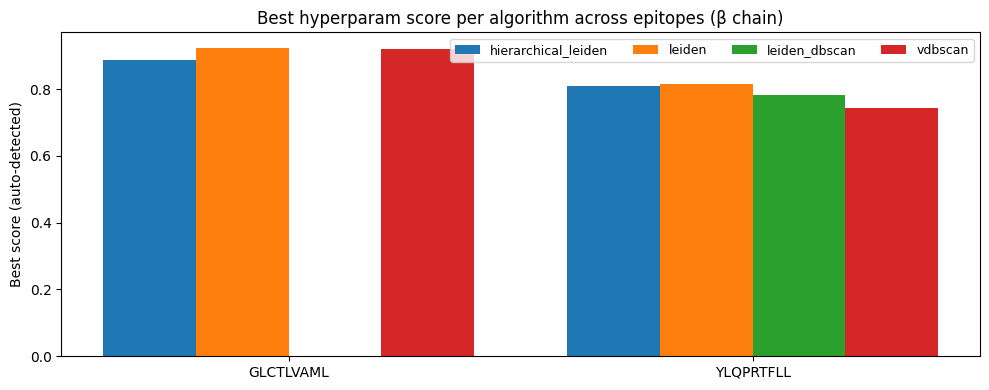

In [16]:

if not comp.empty:
    # pivot to epitope x algo
    piv = comp.pivot_table(index="epitope", columns="algo", values="best_score", aggfunc="max")
    display(piv)

    # grouped bar plot
    plt.figure(figsize=(10, 4))
    epitopes = list(piv.index)
    algos = list(piv.columns)
    x = np.arange(len(epitopes))
    width = 0.8 / max(1, len(algos))

    for i, algo in enumerate(algos):
        vals = piv[algo].values
        plt.bar(x + i * width, vals, width=width, label=algo)

    plt.xticks(x + width*(len(algos)-1)/2, epitopes)
    plt.ylabel("Best score (auto-detected)")
    plt.title("Best hyperparam score per algorithm across epitopes (β chain)")
    plt.legend(ncol=min(4, len(algos)), fontsize=9)
    plt.tight_layout()
    plt.show()


## Notes / quick tweaks
- If your hyperparam TSV uses a different main metric (e.g. `f1_wo_singletons`), it will be auto-detected.
- If you want to force a score column, replace `infer_score_column(df)` with a constant string.
- If your metrics files are in a different place, adjust `find_metrics_files()` or set `METRICS_SUBDIR`.
- If you want baseline *with V/J*, set `baseline_use_vj=True` in `run_epitope_report()`.
